# Transfer learning notebook

This notebook loads a CNN trained to do denoising on the BRATS dataset (young people, tumor, low resolution, multi-sequence) and uses the features learned in its backbone to predict multiple different demographic objects from a single central slice of the brain (age, sex, MR magnetic field etc...)

This shows how AI learns a generic representation of the objects investigated!

In this folder you find a pretrained neural network. Feel free to use your pretrained one!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf


I0000 00:00:1779983803.650750  733319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779983807.471816  733319 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779983820.001772  733319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Limita TF a usare massimo 8GB (8192 MB)
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=15*1024)]
        )

    except RuntimeError as e:
        print(e)

In [ ]:
import keras

In [ ]:
backBone = keras.models.load_model('/mnt/d/dati_corso/AI_denoise/finalTrain_28_05.keras')

I0000 00:00:1779983838.925543  733319 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15360 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
backBone.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 192, 192,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 192, 192,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 192, 192,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 96, 96,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 96,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 96, 96,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 48, 48,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 48, 48,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 24, 24,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 24, 24,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 24, 24,    │  1,180,160 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 24, 24,    │  1,179,904 │ conv2d_7[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 48, 48,    │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48, 48,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 48, 48,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 48, 48,    │    147,584 │ conv2d_9[0][0]  

 Total params: 11,148,869 (42.53 MB)

 Trainable params: 3,716,289 (14.18 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,432,580 (28.35 MB)

In [ ]:
from keras.layers import Conv2D, Flatten, Dense
from keras.models import Model
bottleneckOutput  = backBone.get_layer(name='conv2d_7').output
# Add a layer to compress all the features in a much smaller vector
dataRed = Conv2D (64,2,strides=2,padding='valid',activation='relu', name = 'dimensionReduction') (bottleneckOutput)
x = Flatten()(dataRed)
newOut = Dense(1) (x)
modelAge = Model(backBone.input,newOut)

** We do not train the "backbone" network. All the information we extract is already in the deepest layer**

In [ ]:
backBone.trainable=False
modelAge.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 192, 192, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dimensionReduction (Conv2D)     │ (None, 12, 12, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         9,217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,902,113 (7.26 MB)

 Trainable params: 140,353 (548.25 KB)

 Non-trainable params: 1,761,760 (6.72 MB)

## Load data

In [ ]:
import pandas as pd
baseDir = '/mnt/e/TesiPanzeri/data/ADNI_T1/BET_N4'
data = np.load(baseDir + '/forTransfLearn.npy')
df = pd.read_csv(baseDir + '/forTransfLearn.csv')

In [ ]:
# Apply normalization: try to see what happens if you don't perform it!
for i in range(data.shape[0]):
    iT = data[i,:,:]
    lT = np.percentile(iT,0.5)
    sV = iT[iT>lT].mean()
    if (sV<1e-5) | (np.isnan(sV)):
        sV=1
    iT/= sV
    data[i,:,:]=iT

/tmp/ipykernel_733319/208733824.py:4: RuntimeWarning: Mean of empty slice.
  sV = iT[iT>lT].mean()
/mnt/d/dati_corso/tfCLEAN/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
data = data[:,:,:,None]
dataTrain = data[:1600,:,:,:]
dataVal = data[1600:,:,:,:]
dfTrain = df[:1600]
dfVal = df[1600:]

In [ ]:
modelAge.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),loss='mse',metrics=['mae'])

In [ ]:
fitHist = modelAge.fit(dataTrain,dfTrain['AGE'].values.reshape(-1,1),
            epochs=200,
            batch_size=32,
            validation_data=(dataVal, dfVal['AGE'].values.reshape(-1,1)))

Epoch 1/200


I0000 00:00:1779983890.225651  733562 service.cc:153] XLA service 0x7faf74031590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779983890.225686  733562 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779983890.390188  733562 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779983890.630343  733562 cuda_dnn.cc:461] Loaded cuDNN version 92200


17/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5172.8722 - mae: 71.3382

I0000 00:00:1779983893.059121  733562 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 1688.9689 - mae: 31.5207 - val_loss: 102.8581 - val_mae: 8.4689
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 55.9437 - mae: 5.9483 - val_loss: 47.7957 - val_mae: 5.6120
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.6222 - mae: 5.6240 - val_loss: 46.8859 - val_mae: 5.5478
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.8330 - mae: 5.6399 - val_loss: 46.6367 - val_mae: 5.5238
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 50.1991 - mae: 5.6609 - val_loss: 46.6787 - val_mae: 5.5351
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.0491 - mae: 5.6041 - val_loss: 47.1156 - val_mae: 5.5294
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.5272 - mae: 5.6256 - val_loss: 46.5915 - val_mae: 5.5302
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 48.8032 - mae: 5.5672 - val_loss: 45.7623 - val_mae: 5.4637
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - lo

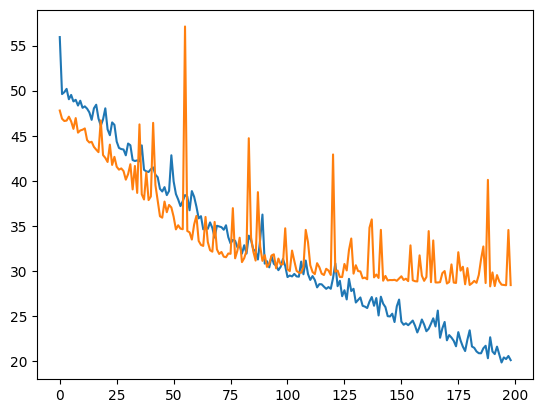

In [ ]:
plt.plot(fitHist.history['loss'][1:])
plt.plot(fitHist.history['val_loss'][1:])
plt.show()

## Validate

In [ ]:
 np.corrcoef(np.squeeze(predAge),dfVal['AGE'].values)[0][1]

np.float64(0.6790076769756552)

### Results: Show the correlation
We achieve a very high level of correlation

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
r^2= 46.1%


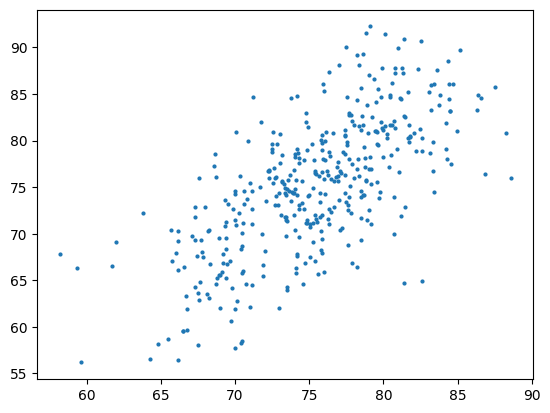

In [ ]:
predAge = modelAge.predict(dataVal)
corrV = np.corrcoef(np.squeeze(predAge),dfVal['AGE'].values)[0][1]
print(f'r^2= {corrV**2:.1%}')
plt.scatter(predAge,dfVal['AGE'].values.reshape(-1,1),s=4)

# Try sex prediction

Now, don't even retrain the "dimension reduction" layer!!

In [ ]:
x = Flatten()(dataRed)
sOut = Dense(1) (x)
modelSex = Model(backBone.input,sOut)
modelSex.get_layer('dimensionReduction').trainable=False

In [ ]:
modelSex.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 192, 192, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dimensionReduction (Conv2D)     │ (None, 12, 12, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         9,217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,902,113 (7.26 MB)

 Trainable params: 9,217 (36.00 KB)

 Non-trainable params: 1,892,896 (7.22 MB)

In [ ]:
modelSex.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-2),loss=keras.losses.BinaryCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
dfTrain['PTGENDER'] = dfTrain['PTGENDER']-1
#dfTrain['PTGENDER'].value_counts()
dfVal['PTGENDER'] = dfVal['PTGENDER']-1

/tmp/ipykernel_733319/719805943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfTrain['PTGENDER'] = dfTrain['PTGENDER']-1
/tmp/ipykernel_733319/719805943.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfVal['PTGENDER'] = dfVal['PTGENDER']-1


In [ ]:
modelSex.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),loss=keras.losses.BinaryCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
fitHist = modelSex.fit(dataTrain,dfTrain['PTGENDER'].values.reshape(-1,1),
            epochs=200,
            batch_size=32,
            validation_data=(dataVal, dfVal['PTGENDER'].values.reshape(-1,1)))

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8813 - loss: 0.2672 - val_accuracy: 0.7250 - val_loss: 0.6436
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8844 - loss: 0.2560 - val_accuracy: 0.7500 - val_loss: 0.6374
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8813 - loss: 0.2521 - val_accuracy: 0.7575 - val_loss: 0.6212
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8863 - loss: 0.2527 - val_accuracy: 0.7600 - val_loss: 0.6196
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8825 - loss: 0.2538 - val_accuracy: 0.7550 - val_loss: 0.6213
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8844 - loss: 0.2480 - val_accuracy: 0.7575 - val_loss: 0.6255
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8825 - loss: 0.2468 - val_accuracy: 0.7575 - val_loss: 0.6198
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8888 - loss: 0.2444 - val_accuracy: 0.7550 - 

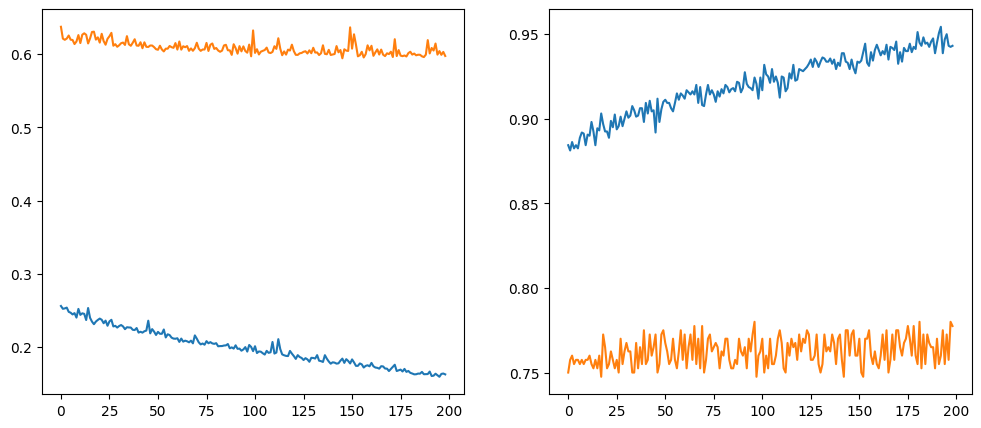

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(fitHist.history['loss'][1:])
plt.plot(fitHist.history['val_loss'][1:])
plt.subplot(122)
plt.plot(fitHist.history['accuracy'][1:])
plt.plot(fitHist.history['val_accuracy'][1:])

## Add augmentation

In [ ]:
from keras import layers

def add_noise_layer(x):
    noise_factor = tf.random.uniform([], 0.0, 0.03)
    noise = noise_factor * tf.random.normal(shape=tf.shape(x))
    return x + noise

def apply_intensity_aug(x):
    gain = tf.random.normal(mean=1, stddev=.1, shape=[])
    x = x * gain
    gamma = tf.random.normal(mean=1, stddev=.1, shape=[])
    x = tf.pow(x, gamma)
    return x

def get_augmentation_model(img_size=(256, 256)):

    inp = layers.Input(shape=(*img_size, 1))

    # 1. Noise + blur
    x = layers.Lambda(add_noise_layer)(inp)
    x = layers.RandomGaussianBlur(
            factor=.7,
            kernel_size=5,
            sigma=.75,
            value_range=(0,2)
        )(x)

    # 2. Spatial + intensity transforms
    x = layers.RandomFlip("vertical")(x)
    x = layers.Lambda(apply_intensity_aug)(x)
    x = layers.RandomRotation(0.02)(x)
    x = layers.RandomZoom(0.05)(x)

    # 3. Optional: add noise again at the end
    x = layers.Lambda(add_noise_layer)(x)

    return keras.Model(inputs=inp, outputs=x)


In [ ]:
augModel = get_augmentation_model(img_size=dataTrain.shape[1:3])

@tf.function
def fast_augment(batch_x):
    return augModel(batch_x, training=True)


In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((dataTrain,dfTrain['PTGENDER'].values.reshape(-1,1) ))

train_ds = (
    train_ds
    .shuffle(1000)
    .batch(32)
    .map(lambda x, y: (fast_augment(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices((dataVal,dfVal['PTGENDER'].values.reshape(-1,1) ))

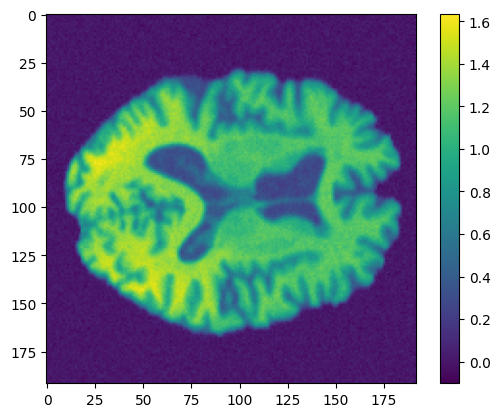

In [ ]:
plt.imshow(x[31,:,:,0])
plt.colorbar()

In [ ]:
x,y = next(iter(train_ds))

In [ ]:
val_ds = (
    val_ds
    .shuffle(1000)
    .batch(32)
)

In [ ]:
modelSex.get_layer('dimensionReduction').trainable=True

In [ ]:
modelSex.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),loss=keras.losses.BinaryCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
fitHist = modelSex.fit(train_ds,
            epochs=50,
            validation_data=val_ds)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5981 - loss: 1.3039 - val_accuracy: 0.7425 - val_loss: 0.6408
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6444 - loss: 0.9412 - val_accuracy: 0.6625 - val_loss: 1.0308
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6388 - loss: 0.8756 - val_accuracy: 0.6500 - val_loss: 1.2174
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6581 - loss: 0.7832 - val_accuracy: 0.6450 - val_loss: 1.2766
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6731 - loss: 0.7673 - val_accuracy: 0.6875 - val_loss: 1.0277
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6606 - loss: 0.7259 - val_accuracy: 0.6750 - val_loss: 1.0926
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6825 - loss: 0.7008 - val_accuracy: 0.6525 - val_loss: 1.1973
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6681 - loss: 0.7256 - val_accuracy: 0.6325 - v

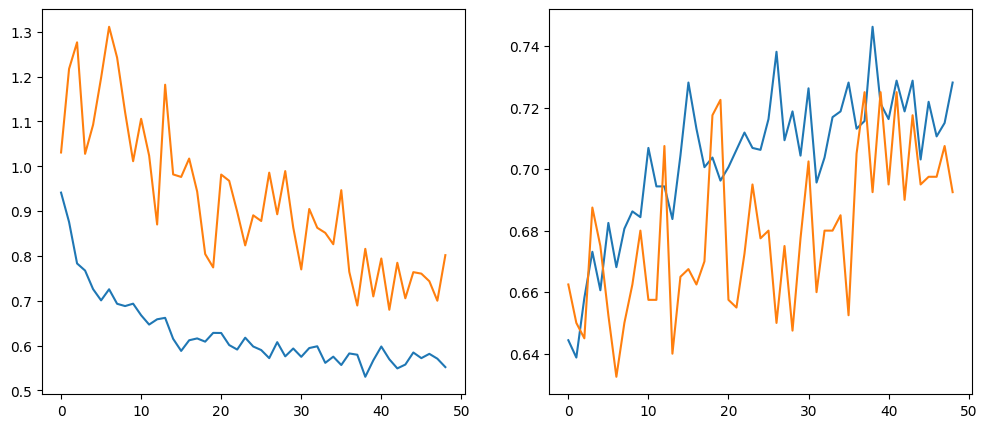

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(fitHist.history['loss'][1:])
plt.plot(fitHist.history['val_loss'][1:])
plt.subplot(122)
plt.plot(fitHist.history['accuracy'][1:])
plt.plot(fitHist.history['val_accuracy'][1:])

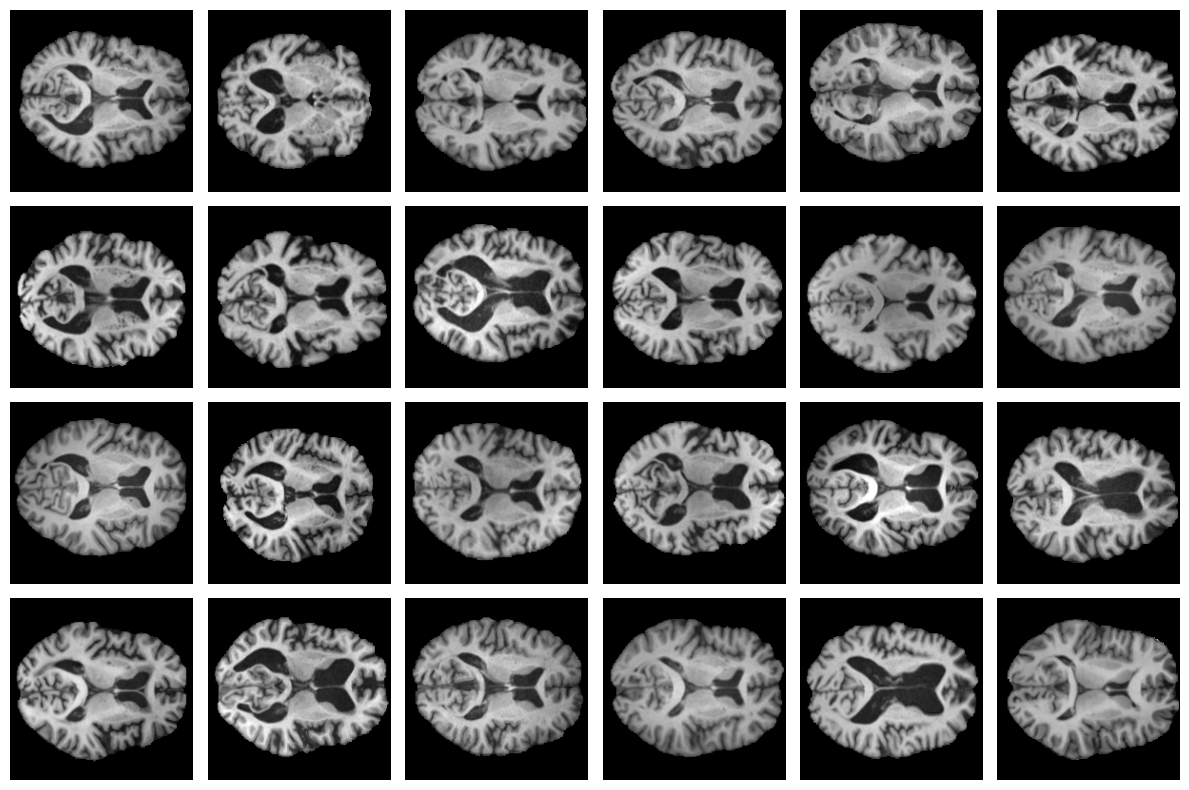

In [ ]:


# dataV.shape = (2000, 192, 192, 1)

# pick 24 random indices
idx = np.random.choice(dataTrain.shape[0], size=24, replace=False)
batch = dataTrain[idx, ..., 0]   # shape (24, 192, 192)

fig, axs = plt.subplots(4, 6, figsize=(12, 8))

for ax, img in zip(axs.ravel(), batch):
    ax.imshow(img, cmap='gray', vmin=0, vmax=2)
    ax.axis('off')

plt.tight_layout()
plt.show()


# Estimate MR field Strenght

In [ ]:
x = Flatten()(dataRed)
fOut = Dense(1) (x)
modelField = Model(backBone.input,fOut)
modelField.get_layer('dimensionReduction').trainable=False

In [ ]:
modelField.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 192, 192, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 192, 192, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dimensionReduction (Conv2D)     │ (None, 12, 12, 64)     │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         9,217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,920,549 (7.33 MB)

 Trainable params: 9,217 (36.00 KB)

 Non-trainable params: 1,892,896 (7.22 MB)

 Optimizer params: 18,436 (72.02 KB)

In [ ]:
modelField.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-2),loss=keras.losses.BinaryCrossentropy(from_logits=True),metrics=['accuracy'])

In [ ]:
dfTrain['MagneticFieldStrength']

0       3.0
1       1.5
2       3.0
3       1.5
4       3.0
       ... 
1595    3.0
1596    1.5
1597    3.0
1598    1.5
1599    3.0
Name: MagneticFieldStrength, Length: 1600, dtype: float64

In [ ]:
trainY = dfTrain['MagneticFieldStrength'].values.reshape(-1,1)>2.0

In [ ]:
valY = dfVal['MagneticFieldStrength'].values.reshape(-1,1)>2.0

In [ ]:
fitHist = modelField.fit(dataTrain,trainY,
            epochs=80,
            batch_size=32,
            validation_data=(dataVal, valY))

Epoch 1/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6231 - loss: 1.3573 - val_accuracy: 0.7500 - val_loss: 0.4702
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7650 - loss: 0.4895 - val_accuracy: 0.3275 - val_loss: 1.6863
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7837 - loss: 0.5012 - val_accuracy: 0.8150 - val_loss: 0.4470
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8225 - loss: 0.3964 - val_accuracy: 0.8300 - val_loss: 0.3523
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8469 - loss: 0.3427 - val_accuracy: 0.7175 - val_loss: 0.4956
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8181 - loss: 0.4279 - val_accuracy: 0.8175 - val_loss: 0.4688
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8288 - loss: 0.4018 - val_accuracy: 0.7950 - val_loss: 0.6289
Epoch 8/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8456 - loss: 0.3515 - val_accuracy: 0.8775 - val_loss

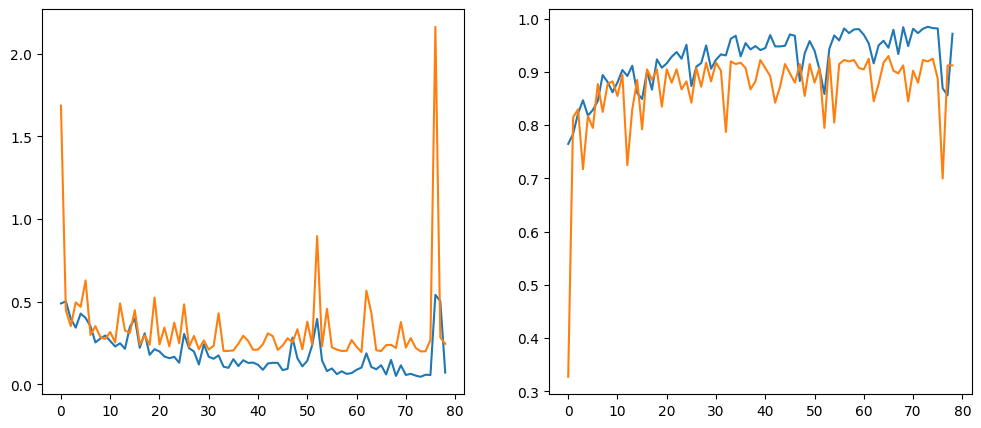

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(fitHist.history['loss'][1:])
plt.plot(fitHist.history['val_loss'][1:])
plt.subplot(122)
plt.plot(fitHist.history['accuracy'][1:])
plt.plot(fitHist.history['val_accuracy'][1:])

In [ ]:
modelField.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),loss=keras.losses.BinaryCrossentropy(from_logits=True),metrics=['accuracy'])
fitHist = modelField.fit(dataTrain,trainY,
            epochs=80,
            batch_size=32,
            validation_data=(dataVal, valY))

Epoch 1/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9900 - loss: 0.0371 - val_accuracy: 0.9200 - val_loss: 0.2413
Epoch 2/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9919 - loss: 0.0350 - val_accuracy: 0.9225 - val_loss: 0.2389
Epoch 3/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9919 - loss: 0.0349 - val_accuracy: 0.9250 - val_loss: 0.2377
Epoch 4/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9912 - loss: 0.0344 - val_accuracy: 0.9200 - val_loss: 0.2372
Epoch 5/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9919 - loss: 0.0347 - val_accuracy: 0.9225 - val_loss: 0.2379
Epoch 6/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9919 - loss: 0.0349 - val_accuracy: 0.9175 - val_loss: 0.2366
Epoch 7/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9919 - loss: 0.0335 - val_accuracy: 0.9200 - val_loss: 0.2371
Epoch 8/80
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9912 - loss: 0.0344 - val_accuracy: 0.9175 - val_loss

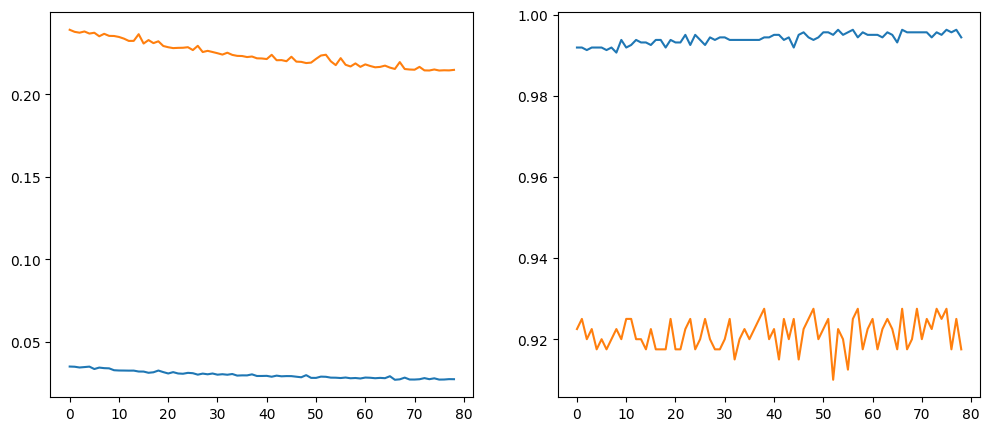

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.plot(fitHist.history['loss'][1:])
plt.plot(fitHist.history['val_loss'][1:])
plt.subplot(122)
plt.plot(fitHist.history['accuracy'][1:])
plt.plot(fitHist.history['val_accuracy'][1:])